In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_features.csv")
df.head()

,customer_unique_id,customer_city,customer_state,total_orders,repeat_customer,total_spent,average_order_value,median_order_value,minimum_order_value,maximum_order_value,...,recency,customer_lifetime_days,customer_age,weekend_purchase_percentage,average_item_price,freight_percentage,purchase_frequency,category_diversity_ratio,low_review_orders,high_review_orders
0,df3bcbcb88d40ad1996ad1325fe8f481,praia grande,SP,1,0,160.28,160.28,160.28,160.28,160.28,...,124,0,124,0.0,80.14,14.349888,inf,0.5,0,1
1,58704dbb44acbec0448a215ac2871320,sao paulo,SP,1,0,70.72,70.72,70.72,70.72,70.72,...,379,0,379,0.0,70.72,16.586538,inf,1.0,0,1
2,e06358b52b33afa8edfe5a0664cfe9c5,ponte serrada,SC,1,0,60.10,60.10,60.10,60.10,60.10,...,240,0,240,0.0,60.10,25.124792,inf,1.0,1,0
3,ee66c72bc9c41ae9de8260314b8088f4,juiz de fora,MG,1,0,247.36,247.36,247.36,247.36,247.36,...,119,0,119,0.0,123.68,19.154269,inf,0.5,0,1
4,c2e79de2c0a7751e26564a3917f9e86d,sao paulo,SP,1,0,115.44,115.44,115.44,115.44,115.44,...,504,0,504,0.0,115.44,13.383576,inf,1.0,0,1


In [3]:
#2. Check Available Geographic Columns
geo_cols = [col for col in df.columns if "state" in col.lower() or
            "city" in col.lower() or
            "zip" in col.lower()]
print(geo_cols)

['customer_city', 'customer_state']


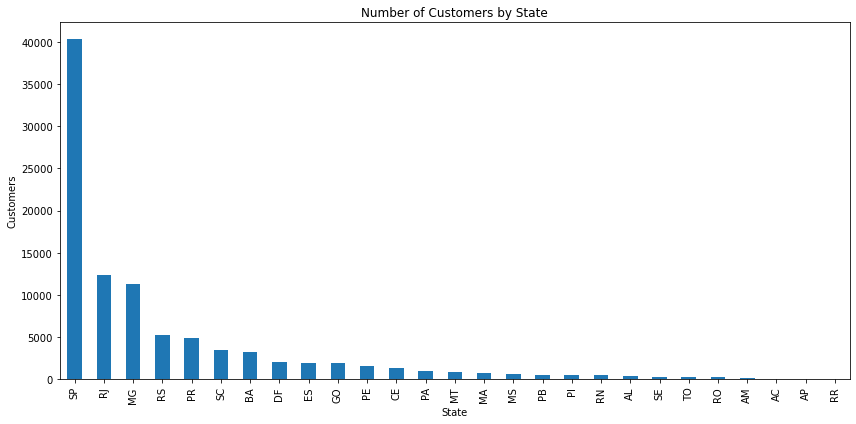

In [4]:
#3. Number of Customers by State
state_customers = (
    df.groupby("customer_state")
      .size()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
state_customers.plot(kind="bar")
plt.title("Number of Customers by State")
plt.xlabel("State")
plt.ylabel("Customers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) Customer distribution is highly concentrated in a few states, indicating that the customer base is not evenly spread across Brazil.

2) The top states account for a significant share of total customers, suggesting stronger market penetration in these regions.

3) States with fewer customers may represent potential markets for future expansion.

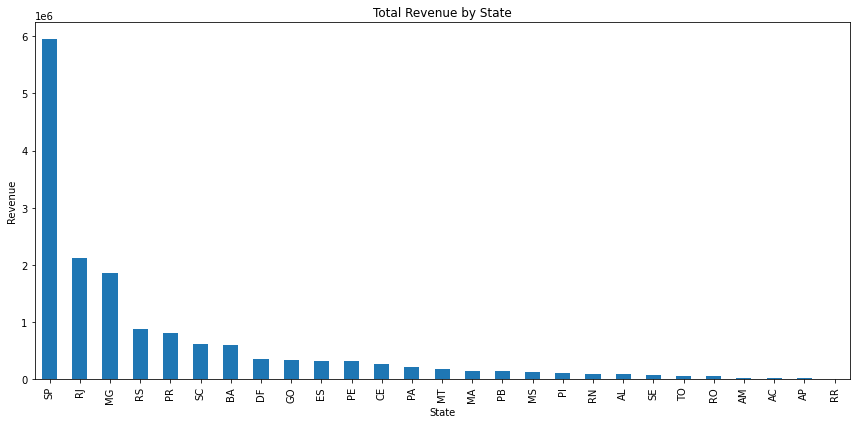

In [5]:
#4. Total Revenue by State
state_sales = (
    df.groupby("customer_state")["total_spent"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
state_sales.plot(kind="bar")
plt.title("Total Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) Revenue is concentrated in a small number of states, indicating that these markets contribute the majority of sales.

2) High customer count generally corresponds to higher revenue, although customer spending patterns also influence total revenue.

3) Low-revenue states may require targeted marketing campaigns or logistics improvements.

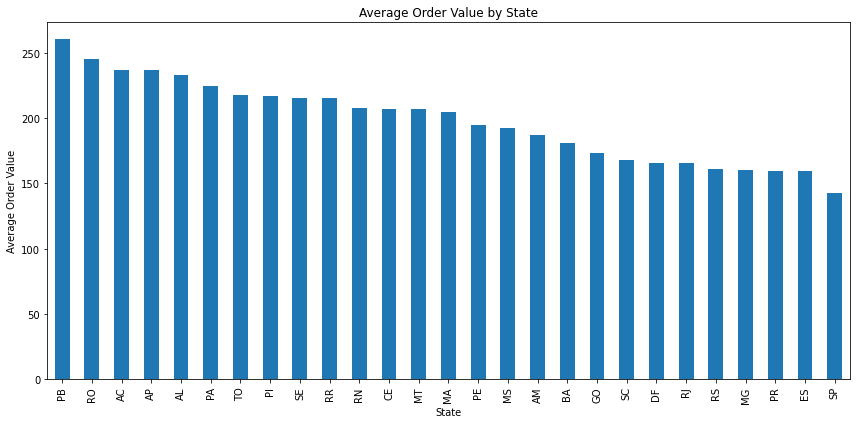

In [6]:
#5. Average Order Value by State
avg_order = (
    df.groupby("customer_state")["average_order_value"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
avg_order.plot(kind="bar")
plt.title("Average Order Value by State")
plt.xlabel("State")
plt.ylabel("Average Order Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) Some states generate fewer orders but have higher average order values, indicating customers purchase higher-priced products.

2) Other states have many customers but relatively lower order values, suggesting opportunities for upselling and cross-selling.

3) Geographic differences in purchasing power may explain variations in spending behavior.

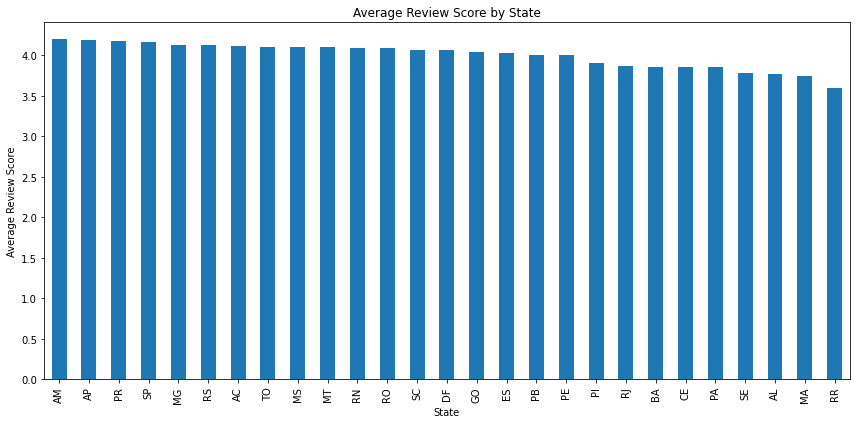

In [7]:
#6. Average Review Score by State
review_state = (
    df.groupby("customer_state")["average_review"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
review_state.plot(kind="bar")
plt.title("Average Review Score by State")
plt.xlabel("State")
plt.ylabel("Average Review Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) States with consistently higher review scores indicate better customer satisfaction and service quality.

2) Lower-rated states may require investigation into delivery performance, product quality, or seller performance.

3) Customer satisfaction varies geographically and can influence future purchasing behavior.

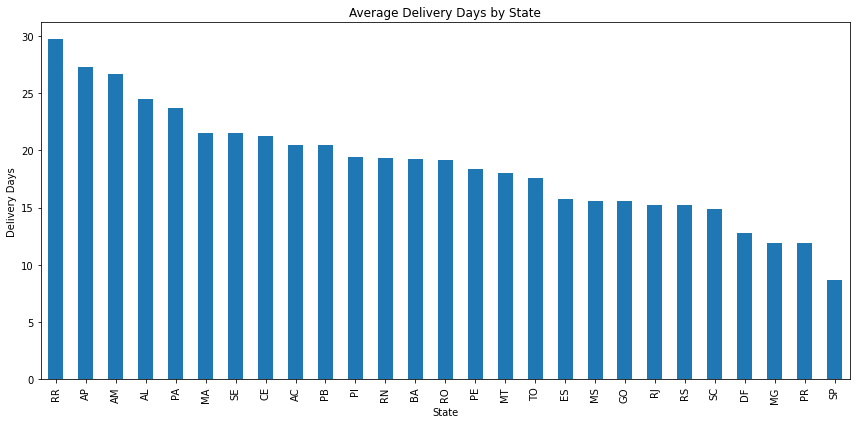

In [8]:
#7. Average Delivery Days by State
delivery_state = (
    df.groupby("customer_state")["average_delivery_days"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
delivery_state.plot(kind="bar")
plt.title("Average Delivery Days by State")
plt.xlabel("State")
plt.ylabel("Delivery Days")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) Delivery times vary significantly across states due to distance from sellers or logistics infrastructure.

2) Customers in remote regions experience longer delivery times compared to major metropolitan areas.

3) Faster deliveries may contribute to improved customer satisfaction and repeat purchases.

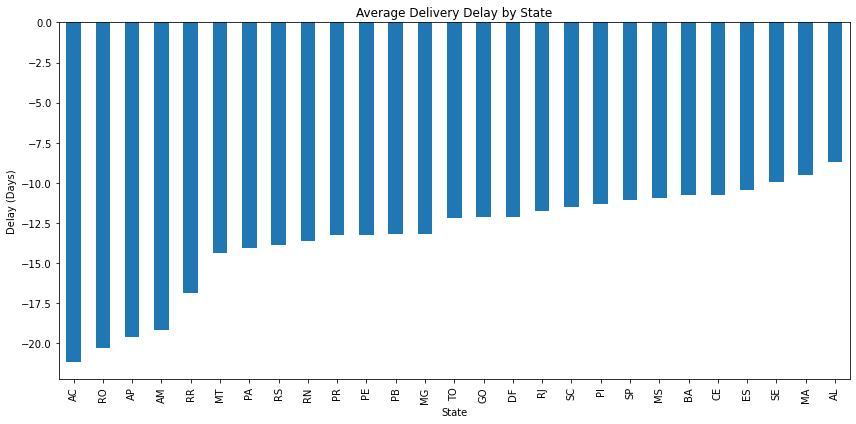

In [9]:
#8. Average Delivery Delay by State
delay_state = (
    df.groupby("customer_state")["average_delivery_delay"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))
delay_state.plot(kind="bar")
plt.title("Average Delivery Delay by State")
plt.xlabel("State")
plt.ylabel("Delay (Days)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) Certain states consistently experience delivery delays, indicating operational bottlenecks.

2) Regions with minimal delays demonstrate stronger logistics performance.

3) Reducing delays in underperforming states could improve customer experience and ratings.

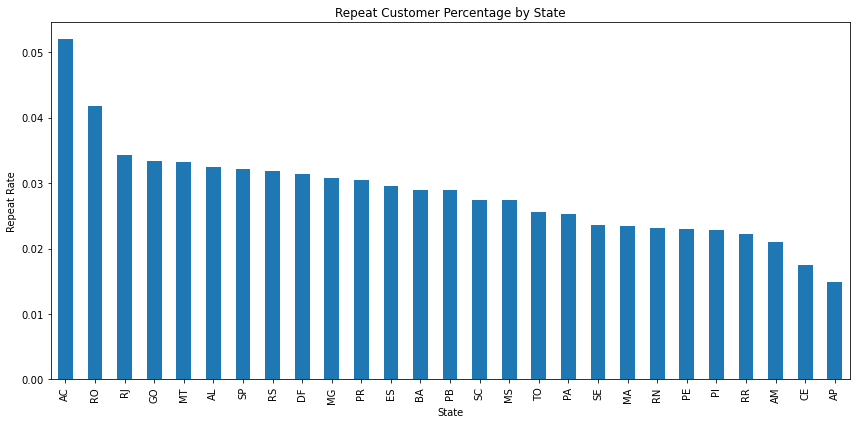

In [10]:
#9. Repeat Customer Percentage by State
repeat_state = (
    df.groupby("customer_state")["repeat_customer"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
repeat_state.plot(kind="bar")
plt.title("Repeat Customer Percentage by State")
plt.xlabel("State")
plt.ylabel("Repeat Rate")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) States with higher repeat customer rates indicate stronger customer loyalty.

2) Lower repeat rates may suggest challenges in customer retention or satisfaction.

3) Customer retention strategies could be prioritized in states with lower repeat purchase behavior.

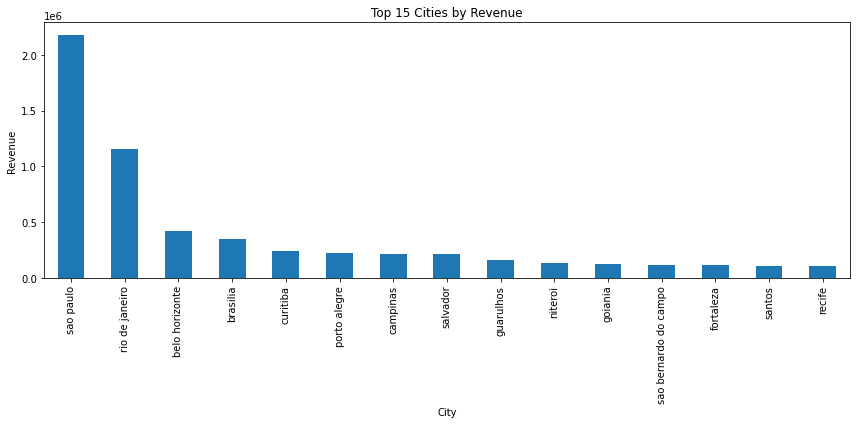

In [11]:
#10. Top 15 Cities by Revenue
city_sales = (
    df.groupby("customer_city")["total_spent"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(12,6))
city_sales.plot(kind="bar")
plt.title("Top 15 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) Revenue is concentrated in a few major cities, reflecting higher purchasing activity in urban markets.

2) Large metropolitan cities contribute disproportionately to total sales.

3) These cities represent strategic markets for targeted promotions and inventory planning.

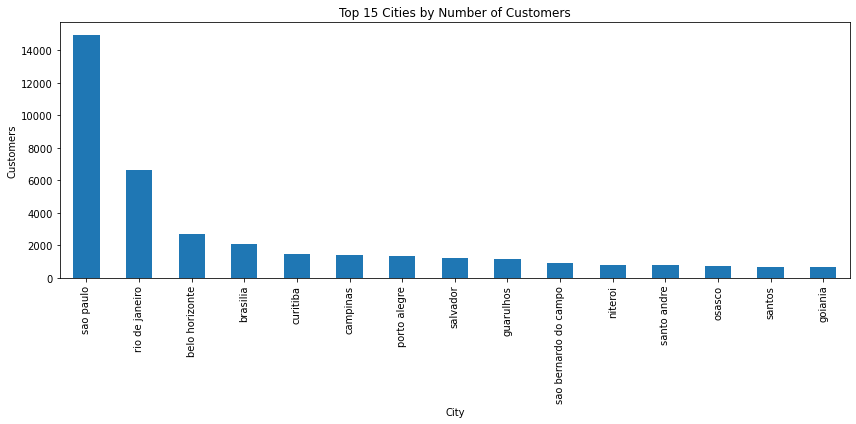

In [12]:
#11. Top 15 Cities by Customers
city_customers = (
    df.groupby("customer_city")
      .size()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(12,6))
city_customers.plot(kind="bar")
plt.title("Top 15 Cities by Number of Customers")
plt.xlabel("City")
plt.ylabel("Customers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) Customer concentration is highest in major urban centers.

2) Large cities offer opportunities for personalized marketing campaigns due to their sizable customer base.

3) Smaller cities may have untapped growth potential.

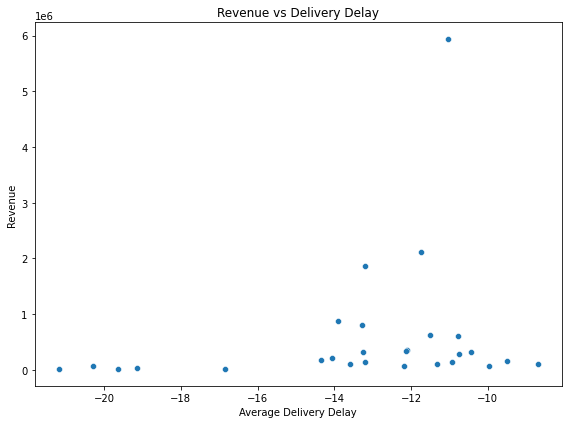

In [13]:
#12. Revenue vs Delivery Delay
state_summary = (
    df.groupby("customer_state")
      .agg({
          "total_spent":"sum",
          "average_delivery_delay":"mean"
      })
)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=state_summary,
    x="average_delivery_delay",
    y="total_spent"
)
plt.title("Revenue vs Delivery Delay")
plt.xlabel("Average Delivery Delay")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

1) States with longer delivery delays do not necessarily generate lower revenue, indicating customers may tolerate delays in high-demand markets.

2) However, extremely high delays could eventually impact customer satisfaction and future purchases.

3) Improving delivery performance in high-revenue regions could strengthen long-term customer loyalty.

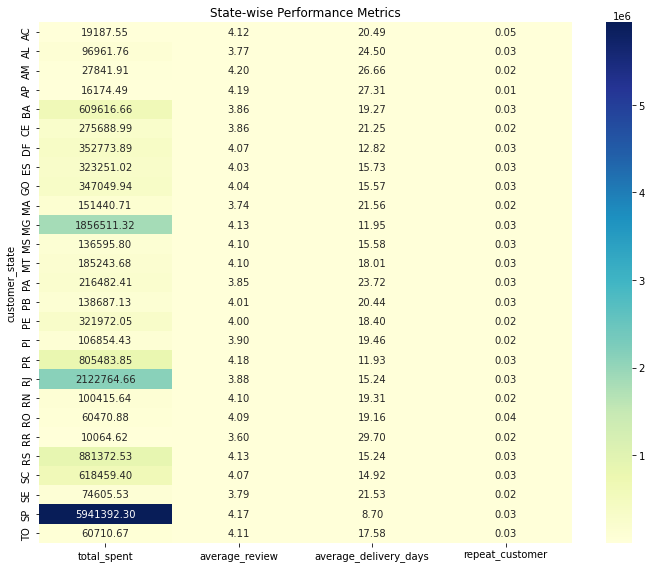

In [14]:
#13. Heatmap of State-Level Metrics
state_metrics = (
    df.groupby("customer_state")
      .agg({
          "total_spent":"sum",
          "average_review":"mean",
          "average_delivery_days":"mean",
          "repeat_customer":"mean"
      })
)
plt.figure(figsize=(10,8))
sns.heatmap(
    state_metrics,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)
plt.title("State-wise Performance Metrics")
plt.tight_layout()
plt.show()

1) The heatmap highlights considerable variation across states in spending, reviews, delivery performance, and repeat purchases.

2) Some states perform well across all metrics, while others exhibit weaknesses in one or more areas.

3) This analysis helps identify regions requiring operational improvements or marketing interventions.

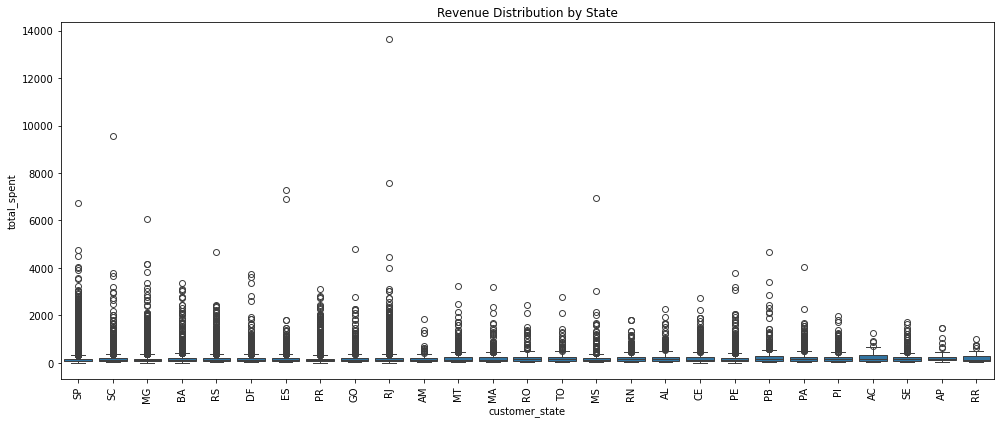

In [15]:
#14. Revenue Distribution Across States (Boxplot)
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x="customer_state",
    y="total_spent"
)
plt.title("Revenue Distribution by State")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

1) Revenue distribution is positively skewed, with a few customers contributing exceptionally high spending.

2) Most customers have relatively moderate spending levels, while high-value customers appear as outliers.

3) Businesses can identify and retain these high-value customers through loyalty programs and personalized offers.

##### Overall Geographical Business Insights

At the end of the notebook, include a summary like this:

**Key Geographical Findings**

1) Customer activity is concentrated in a limited number of economically developed states and metropolitan cities.

2) Revenue distribution closely follows customer concentration, although average spending varies across regions.

3) Delivery performance differs significantly by geography, highlighting opportunities for logistics optimization.

4) States with faster deliveries generally exhibit better customer satisfaction and stronger repeat purchase behavior.

5) Geographic segmentation enables businesses to identify high-performing markets, prioritize logistics improvements, and design region-specific marketing strategies.

6) Understanding regional differences helps optimize resource allocation, improve customer experience, and maximize long-term profitability.